In [39]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


import mkssins
from mkssins import *
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import matplotlib as mpl
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.facecolor'] = 'none'

In [13]:
import os
import pickle

folder_path = 'ssins_iterative_flags/ssins_level0/'  # Replace with your folder path
data = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_ssins_Level0_flags.pickle') or filename.endswith('_h_ssins_Level0_flags.npy'):
        print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data[file_prefix] = np.load(file)
            fname.append(file_prefix)
        
print(f"Loaded {len(data)} pickle files.")


1634402485_h_ssins_Level0_flags.npy
1634252028_h_ssins_Level0_flags.npy
1638130295_h_ssins_Level0_flags.npy
1637691677_h_ssins_Level0_flags.npy
1631732038_h_ssins_Level0_flags.npy
1632077222_h_ssins_Level0_flags.npy
1631667564_h_ssins_Level0_flags.npy
1638294319_h_ssins_Level0_flags.npy
1637354605_h_ssins_Level0_flags.npy
1638386189_h_ssins_Level0_flags.npy
1630519596_h_ssins_Level0_flags.npy
1638639082_h_ssins_Level0_flags.npy
1632184922_h_ssins_Level0_flags.npy
1631990463_h_ssins_Level0_flags.npy
1638301944_h_ssins_Level0_flags.npy
1631559762_h_ssins_Level0_flags.npy
1637346562_h_ssins_Level0_flags.npy
1639157507_h_ssins_Level0_flags.npy
1631818149_h_ssins_Level0_flags.npy
1631387336_h_ssins_Level0_flags.npy
1637699408_h_ssins_Level0_flags.npy
1632069690_h_ssins_Level0_flags.npy
1631982988_h_ssins_Level0_flags.npy
1631810671_h_ssins_Level0_flags.npy
1632760885_h_ssins_Level0_flags.npy
1640799689_h_ssins_Level0_flags.npy
Loaded 26 pickle files.


In [14]:
for f in fname:
    print(f)

1634402485
1634252028
1638130295
1637691677
1631732038
1632077222
1631667564
1638294319
1637354605
1638386189
1630519596
1638639082
1632184922
1631990463
1638301944
1631559762
1637346562
1639157507
1631818149
1631387336
1637699408
1632069690
1631982988
1631810671
1632760885
1640799689


In [8]:
data

{'1630519596': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 '1631387336': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 '1631559762': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
   

In [61]:
pol = 'h'
path_l1 = '/idia/projects/hi_im/raw_vis/MeerKLASS2021/level1/mask/checked/'

In [62]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

data_katcali = []

# Iterate through the files for each observation
for i, f in enumerate(fname):  # Limit to first two files
    print(f)
    
    data_file = kio.load_data(f)
    freqs = data_file.freqs  # Array of frequencies
    chans = data_file.channels
    l1_flags, nrec = l1_flags_dict_to_array(fname=f'{f}', pol='h', path=path_l1)
    katcali_flag_counts_l1 = count_flags(l1_flags)

    # Ensure `katcali_flag_counts_l1['flags_fchan']` is an array of the same length as freqs
    flagged_percentages = katcali_flag_counts_l1['flags_fchan']

    # Store each frequency and its corresponding flagged percentage
    for freq, flag in zip(freqs/1e6, flagged_percentages):
        freq_cut = round(freq, 3) 
        data_katcali.append([f, freq_cut, flag]) 

# Create DataFrame
df = pd.DataFrame(data_katcali, columns=["Observation", "Frequency", "% Flagged Channels"])

# Use `pivot_table()` instead of `pivot()`
df_pivot = df.pivot_table(index="Observation", columns="Frequency", values="% Flagged Channels", aggfunc="mean")


1634402485


mask2 loaded for dish m001
mask2 loaded for dish m002
mask2 loaded for dish m004
mask2 loaded for dish m005
mask2 loaded for dish m007
mask2 loaded for dish m009
mask2 loaded for dish m010
mask2 loaded for dish m011
mask2 loaded for dish m012
mask2 loaded for dish m013
mask2 loaded for dish m014
mask2 loaded for dish m015
mask2 loaded for dish m016
mask2 loaded for dish m017
mask2 loaded for dish m018
mask2 loaded for dish m019
mask2 loaded for dish m020
mask2 loaded for dish m021
mask2 loaded for dish m022
mask2 loaded for dish m023
mask2 loaded for dish m024
mask2 loaded for dish m025
mask2 loaded for dish m026
mask2 loaded for dish m027
mask2 loaded for dish m028
mask2 loaded for dish m029
mask2 loaded for dish m030
mask2 loaded for dish m031
mask2 loaded for dish m032
mask2 loaded for dish m033
mask2 loaded for dish m036
mask2 loaded for dish m037
mask2 loaded for dish m039
mask2 loaded for dish m040
mask2 loaded for dish m041
mask2 loaded for dish m043
mask2 loaded for dish m044
m

mask loaded for dish m001
mask loaded for dish m002
mask loaded for dish m003
mask loaded for dish m004
mask loaded for dish m005
mask loaded for dish m006
mask loaded for dish m007
mask loaded for dish m008
mask loaded for dish m009
mask loaded for dish m010
mask loaded for dish m011
mask loaded for dish m012
mask loaded for dish m013
mask loaded for dish m015
mask loaded for dish m016
mask loaded for dish m017
mask loaded for dish m018
mask loaded for dish m019
mask loaded for dish m020
mask loaded for dish m021
mask loaded for dish m022
mask loaded for dish m023
mask loaded for dish m025
mask loaded for dish m026
mask loaded for dish m027
mask loaded for dish m028
mask loaded for dish m030
mask loaded for dish m031
mask loaded for dish m032
mask loaded for dish m034
mask loaded for dish m036
mask loaded for dish m037
mask loaded for dish m038
mask loaded for dish m039
mask loaded for dish m040
mask loaded for dish m041
mask loaded for dish m042
mask loaded for dish m043
mask loaded 

mask2 loaded for dish m000
mask2 loaded for dish m002
mask2 loaded for dish m005
mask2 loaded for dish m009
mask2 loaded for dish m010
mask2 loaded for dish m012
mask2 loaded for dish m022
mask2 loaded for dish m029
mask2 loaded for dish m040
mask2 loaded for dish m042
mask2 loaded for dish m046
mask2 loaded for dish m047
mask2 loaded for dish m053
mask2 loaded for dish m056
mask2 loaded for dish m058
1637691677


mask2 loaded for dish m000
mask2 loaded for dish m002
mask2 loaded for dish m005
mask2 loaded for dish m006
mask2 loaded for dish m007
mask2 loaded for dish m009
mask2 loaded for dish m010
mask2 loaded for dish m011
mask2 loaded for dish m012
mask2 loaded for dish m015
mask2 loaded for dish m017
mask2 loaded for dish m018
mask2 loaded for dish m019
mask2 loaded for dish m020
mask2 loaded for dish m021
mask2 loaded for dish m027
mask2 loaded for dish m029
mask2 loaded for dish m038
mask2 loaded for dish m039
mask2 loaded for dish m040
mask2 loaded for dish m041
mask2 loaded for dish m042
mask2 loaded for dish m043
mask2 loaded for dish m044
mask2 loaded for dish m045
mask2 loaded for dish m046
mask2 loaded for dish m047
mask2 loaded for dish m048
mask2 loaded for dish m049
mask2 loaded for dish m051
mask2 loaded for dish m054
mask2 loaded for dish m056
mask2 loaded for dish m057
mask2 loaded for dish m058
mask2 loaded for dish m059
mask2 loaded for dish m060
mask2 loaded for dish m062
1

...

mask2 loaded for dish m000
mask2 loaded for dish m001
mask2 loaded for dish m002
mask2 loaded for dish m003
mask2 loaded for dish m004
mask2 loaded for dish m005
mask2 loaded for dish m006
mask2 loaded for dish m007
mask2 loaded for dish m008
mask2 loaded for dish m009
mask2 loaded for dish m010
mask2 loaded for dish m011
mask2 loaded for dish m012
mask2 loaded for dish m014
mask2 loaded for dish m015
mask2 loaded for dish m017
mask2 loaded for dish m018
mask2 loaded for dish m019
mask2 loaded for dish m020
mask2 loaded for dish m021
mask2 loaded for dish m022
mask2 loaded for dish m023
mask2 loaded for dish m024
mask2 loaded for dish m025
mask2 loaded for dish m026
mask2 loaded for dish m027
mask2 loaded for dish m028
mask2 loaded for dish m029
mask2 loaded for dish m030
mask2 loaded for dish m031
mask2 loaded for dish m032
mask2 loaded for dish m034
mask2 loaded for dish m035
mask2 loaded for dish m037
mask2 loaded for dish m038
mask2 loaded for dish m040
mask2 loaded for dish m041
m

mask2 loaded for dish m000
mask2 loaded for dish m002
mask2 loaded for dish m003
mask2 loaded for dish m004
mask2 loaded for dish m005
mask2 loaded for dish m006
mask2 loaded for dish m007
mask2 loaded for dish m008
mask2 loaded for dish m009
mask2 loaded for dish m010
mask2 loaded for dish m011
mask2 loaded for dish m012
mask2 loaded for dish m014
mask2 loaded for dish m015
mask2 loaded for dish m017
mask2 loaded for dish m018
mask2 loaded for dish m019
mask2 loaded for dish m020
mask2 loaded for dish m021
mask2 loaded for dish m022
mask2 loaded for dish m023
mask2 loaded for dish m024
mask2 loaded for dish m025
mask2 loaded for dish m026
mask2 loaded for dish m028
mask2 loaded for dish m029
mask2 loaded for dish m030
mask2 loaded for dish m031
mask2 loaded for dish m032
mask2 loaded for dish m033
mask2 loaded for dish m034
mask2 loaded for dish m035
mask2 loaded for dish m036
mask2 loaded for dish m037
mask2 loaded for dish m038
mask2 loaded for dish m040
mask2 loaded for dish m041
m

mask2 loaded for dish m000
mask loaded for dish m002
mask loaded for dish m003
mask loaded for dish m004
mask loaded for dish m005
mask loaded for dish m006
mask loaded for dish m007
mask loaded for dish m008
mask loaded for dish m009
mask loaded for dish m010
mask loaded for dish m011
mask loaded for dish m012
mask loaded for dish m014
mask loaded for dish m015
mask loaded for dish m016
mask loaded for dish m017
mask loaded for dish m018
mask loaded for dish m019
mask loaded for dish m020
mask loaded for dish m021
mask loaded for dish m022
mask loaded for dish m023
mask loaded for dish m024
mask loaded for dish m025
mask loaded for dish m026
mask loaded for dish m027
mask loaded for dish m028
mask loaded for dish m029
mask loaded for dish m030
mask loaded for dish m031
mask loaded for dish m032
mask loaded for dish m034
mask loaded for dish m035
mask loaded for dish m036
mask loaded for dish m037
mask loaded for dish m038
mask loaded for dish m039
mask loaded for dish m040
mask loaded

mask loaded for dish m000
mask loaded for dish m001
mask loaded for dish m002
mask loaded for dish m003
mask loaded for dish m004
mask loaded for dish m005
mask loaded for dish m006
mask loaded for dish m007
mask loaded for dish m009
mask loaded for dish m010
mask loaded for dish m011
mask loaded for dish m012
mask loaded for dish m014
mask loaded for dish m016
mask loaded for dish m017
mask loaded for dish m018
mask loaded for dish m019
mask loaded for dish m020
mask loaded for dish m022
mask loaded for dish m023
mask loaded for dish m026
mask loaded for dish m027
mask loaded for dish m028
mask loaded for dish m029
mask loaded for dish m032
mask loaded for dish m040
mask loaded for dish m041
mask loaded for dish m042
mask loaded for dish m043
mask loaded for dish m046
mask loaded for dish m048
mask loaded for dish m049
mask loaded for dish m050
mask loaded for dish m053
mask loaded for dish m058
mask loaded for dish m059
mask loaded for dish m062
1640799689


mask loaded for dish m059
mask loaded for dish m060


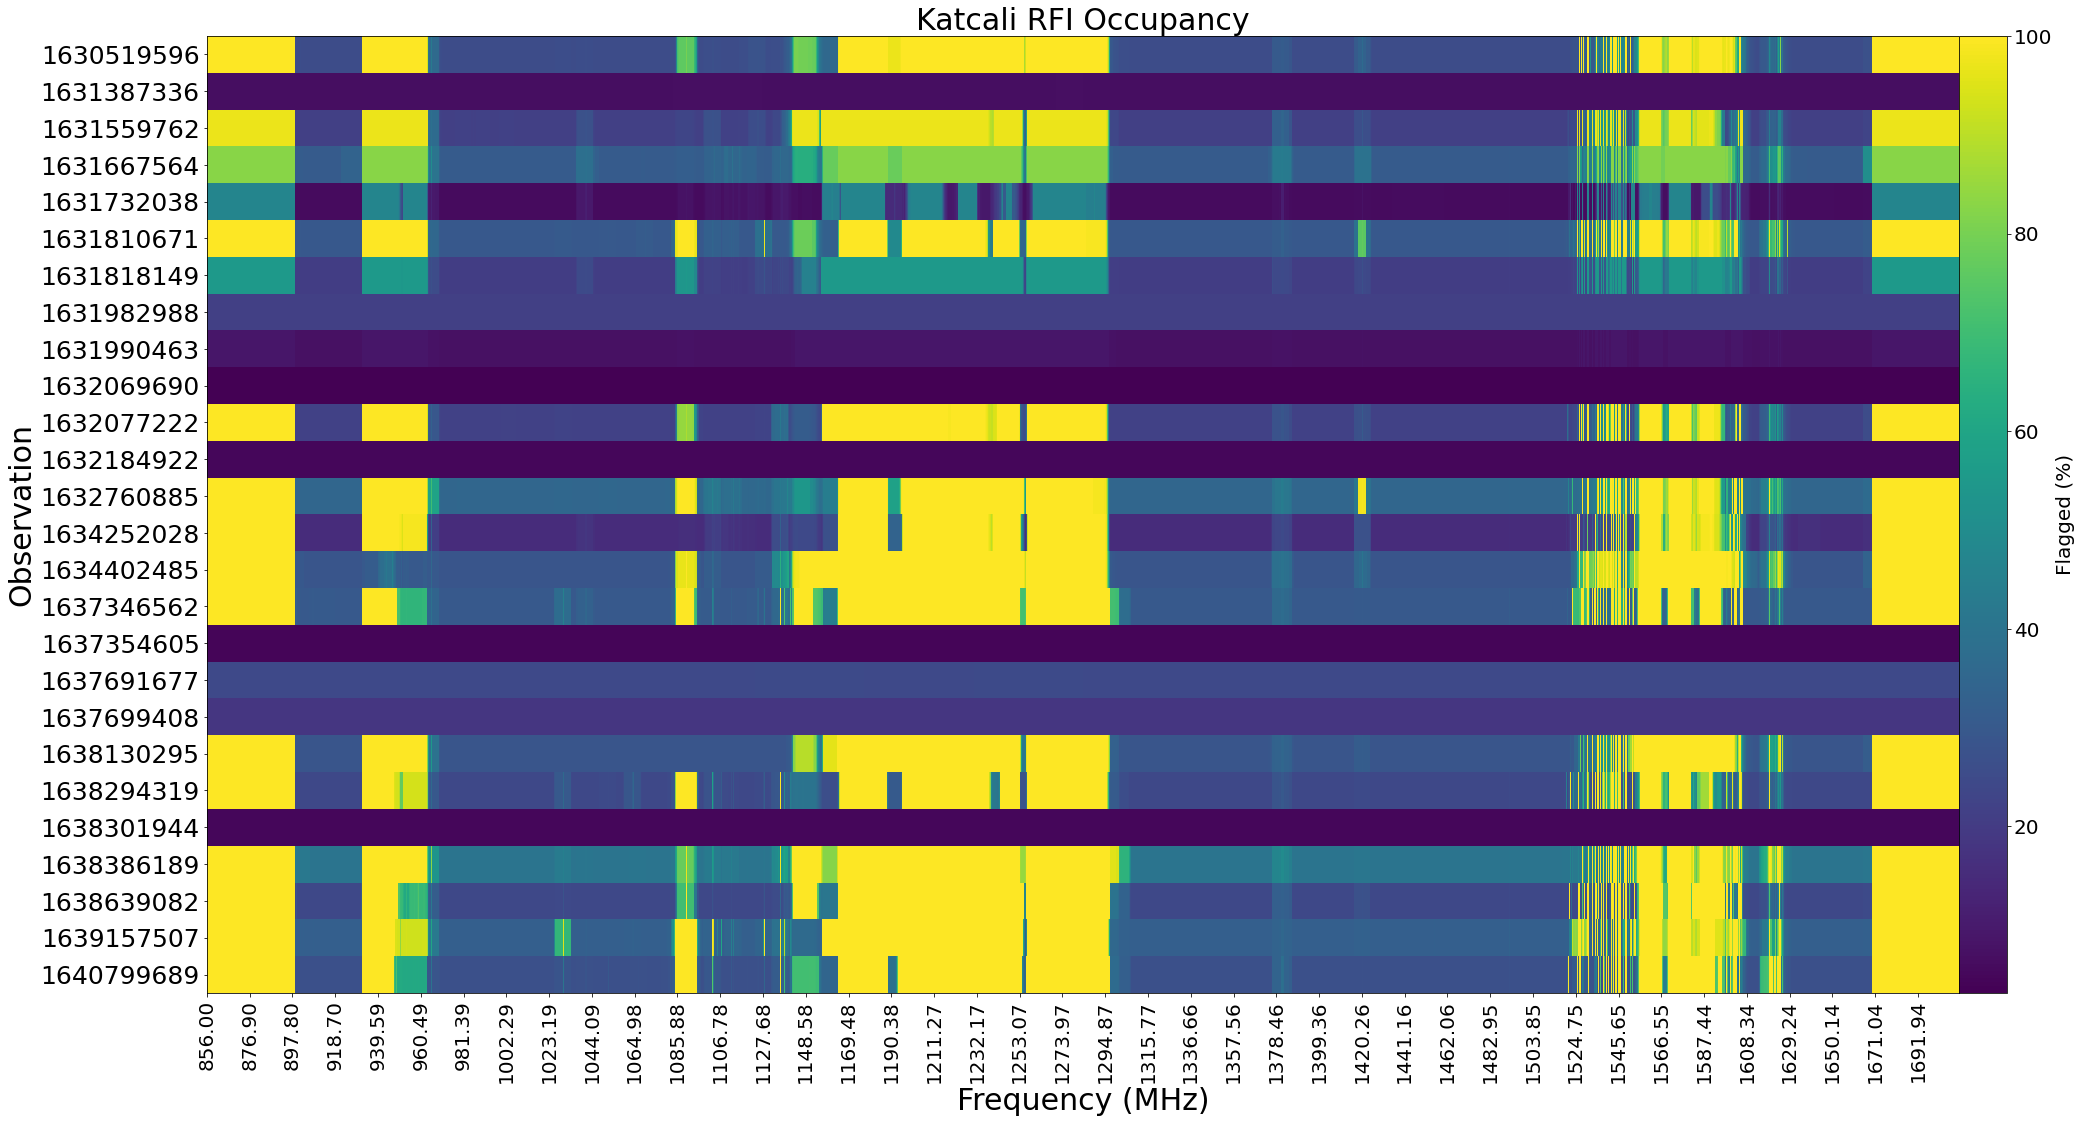

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(32, 16))
cax = ax.imshow(df_pivot.values.astype(float), aspect='auto', cmap='viridis', interpolation='none')

# Add colorbar directly next to the plot
cbar = fig.colorbar(cax, ax=ax, pad=0.00)  # pad controls the gap
cbar.set_label("Flagged (%)")

# Set titles and labels
ax.set_title("Katcali RFI Occupancy", fontsize=30)
ax.set_ylabel("Observation", fontsize=30)
ax.set_xlabel("Frequency (MHz)", fontsize=30)

# Y-axis: all observations
ax.set_yticks(np.arange(len(df_pivot.index)))
ax.set_yticklabels(df_pivot.index, fontsize=30)

# X-axis: every 10th frequency label
freqs = df_pivot.columns
xtick_positions = np.arange(len(freqs))[::100]
xtick_labels = [f"{freqs[i]:.2f}" for i in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=90)

plt.tight_layout()
plt.show()


In [58]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

data_ssins = []

# Iterate through the files for each observation
for i, f in enumerate(fname):  # Limit to first two files
    print(f)
    
    data_file = kio.load_data(f)
    ants = [a.name for a in data_file.ants]
    nrec = len(ants)
    freqs = data_file.freqs  # Array of frequencies
    chans = data_file.channels
    #l1_flags, nrec = l1_flags_dict_to_array(fname=f'{f}', pol='h', path=path_l1)
    with open(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', 'rb') as flag:
        ssins_flags_l0 = np.load(flag, allow_pickle=True)
    
    ssins_flag_counts_l1 = count_flags(ssins_flags_l0, nreceiver=nrec)

    # Ensure `katcali_flag_counts_l1['flags_fchan']` is an array of the same length as freqs
    flagged_percentages = ssins_flag_counts_l1['flags_fchan']

    # Store each frequency and its corresponding flagged percentage
    for freq, flag in zip(freqs/1e6, flagged_percentages):
        freq_cut = round(freq, 3) 
        data_ssins.append([f, freq_cut, flag]) 

# Create DataFrame
df_ssins = pd.DataFrame(data_ssins, columns=["Observation", "Frequency", "% Flagged Channels"])

# Use `pivot_table()` instead of `pivot()`
df_pivot_ssins = df_ssins.pivot_table(index="Observation", columns="Frequency", values="% Flagged Channels", aggfunc="mean")


1634402485


1634252028


1638130295


1637691677


1631732038


...

1632069690


1631982988


1631810671


1632760885


1640799689


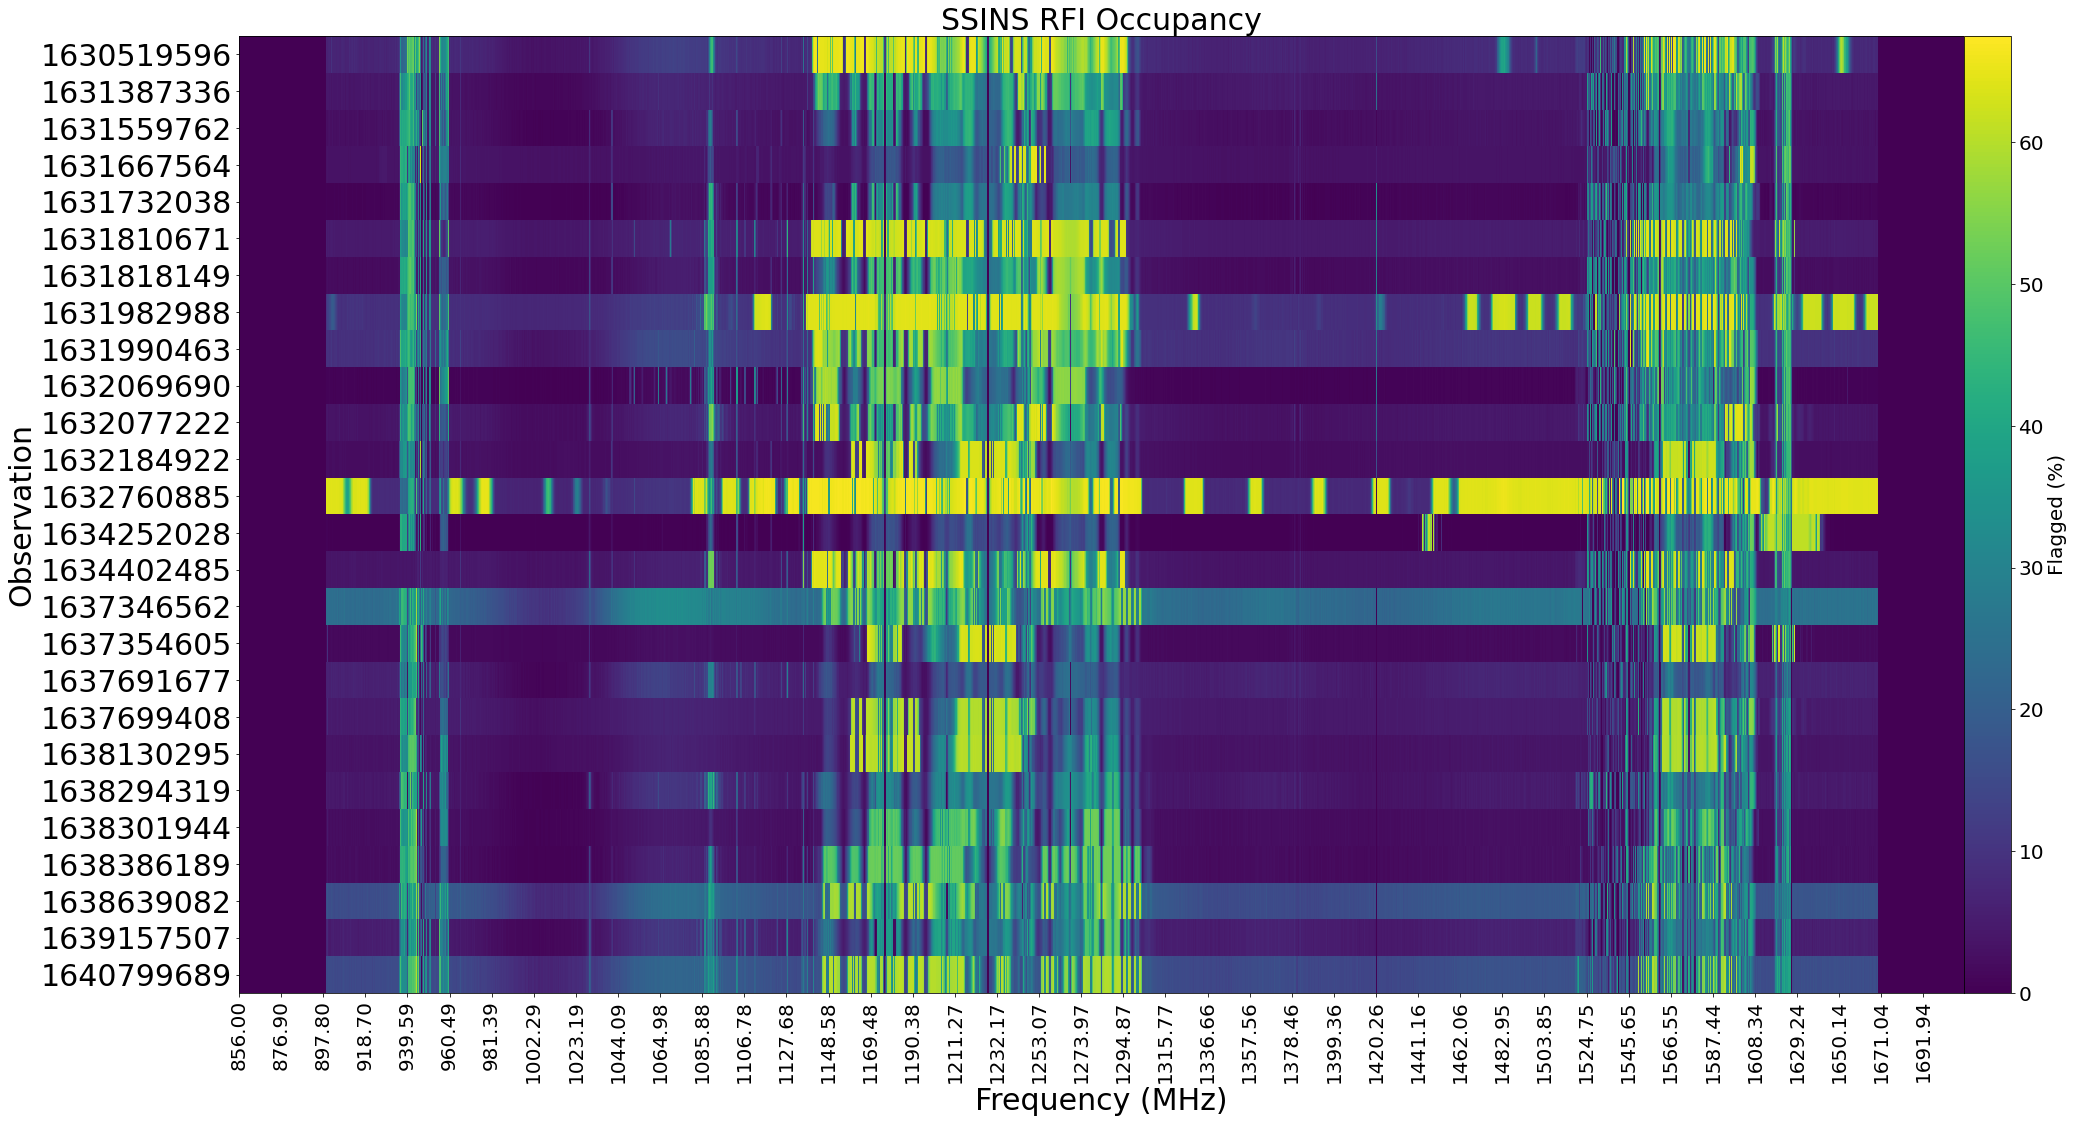

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(32, 16))
cax = ax.imshow(df_pivot_ssins.values.astype(float), aspect='auto', cmap='viridis', interpolation='none')

# Add colorbar directly next to the plot
cbar = fig.colorbar(cax, ax=ax, pad=0.00)  # pad controls the gap
cbar.set_label("Flagged (%)")

# Set titles and labels
ax.set_title("SSINS RFI Occupancy", fontsize=30)
ax.set_ylabel("Observation", fontsize=30)
ax.set_xlabel("Frequency (MHz)", fontsize=30)

# Y-axis: all observations
ax.set_yticks(np.arange(len(df_pivot.index)))
ax.set_yticklabels(df_pivot.index, fontsize=30)

# X-axis: every 10th frequency label
freqs = df_pivot_ssins.columns
xtick_positions = np.arange(len(freqs))[::100]
xtick_labels = [f"{freqs[i]:.2f}" for i in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=90)

plt.tight_layout()
plt.show()

In [60]:
# Create DataFrame
df_ssins = pd.DataFrame(data_ssins, columns=["Observation", "Frequency", "% Flagged Channels"])

# Use `pivot_table()` instead of `pivot()`
df_pivot_ssins = df_ssins.pivot_table(index="Observation", columns="Frequency", values="% Flagged Channels", aggfunc="mean")

